NOTE: This is a research prototype. Code refactoring and optimization are ongoing.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False
df = pd.read_csv(r"D:\project\CN\neuro_data.csv")
df.head(10)

,neuro_id,age_group,frequency,n_trials,spike_count,rat_id
0,1,adult,13000,20,3,20240608
1,1,adult,14000,20,6,20240608
2,1,adult,15000,20,8,20240608
3,1,adult,16000,20,18,20240608
4,1,adult,17000,20,12,20240608
5,1,adult,18000,20,4,20240608
6,1,adult,19000,20,1,20240608
7,1,adult,20000,20,1,20240608
8,2,adult,4000,20,4,20240608
9,2,adult,5000,20,7,20240608


In [3]:
# Count the number of neurons in each age group
neuron_counts = df.groupby('age_group')['neuro_id'].nunique().reset_index()

neuron_counts.columns = ['age_group', 'n_neurons']

print(neuron_counts)

  age_group  n_neurons
0     14-20         69
1     21-30         88
2     adult         86


In [4]:
# Compute firing rate
df['firing_rate'] = df['spike_count']/df['n_trials']
print(df.head())

   neuro_id age_group  frequency  n_trials  spike_count    rat_id  firing_rate
0         1     adult      13000        20            3  20240608         0.15
1         1     adult      14000        20            6  20240608         0.30
2         1     adult      15000        20            8  20240608         0.40
3         1     adult      16000        20           18  20240608         0.90
4         1     adult      17000        20           12  20240608         0.60


In [5]:
#Missing value check
df.isna().sum()

neuro_id       0
age_group      0
frequency      0
n_trials       0
spike_count    0
rat_id         0
firing_rate    0
dtype: int64

In [6]:
#Print column names
print(df.columns.tolist())

['neuro_id', 'age_group', 'frequency', 'n_trials', 'spike_count', 'rat_id', 'firing_rate']


In [7]:
df = df.sort_values(["neuro_id", "frequency"])

In [8]:
df["n_trials"].unique()

array([20])

In [12]:
df.head(5)

,neuro_id,age_group,frequency,n_trials,spike_count,rat_id,firing_rate
0,1,adult,13000,20,3,20240608,0.15
1,1,adult,14000,20,6,20240608,0.30
2,1,adult,15000,20,8,20240608,0.40
3,1,adult,16000,20,18,20240608,0.90
4,1,adult,17000,20,12,20240608,0.60


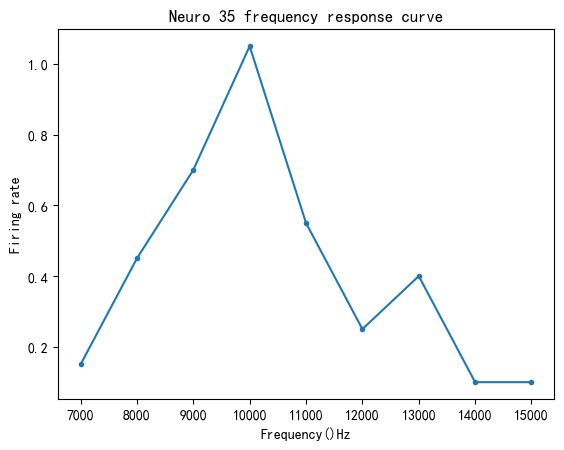

In [13]:
# Frequency response curve example
n = df[df['neuro_id']==35]
plt.plot(n['frequency'],n['firing_rate'],marker=".")
plt.xlabel('Frequency()Hz')
plt.ylabel('Firing rate')
plt.title('Neuro 35 frequency response curve')
plt.show()


In [14]:
#Check for empty curves
zero_neurons = df.groupby("neuro_id")["firing_rate"].max()
zero_neurons = zero_neurons[zero_neurons == 0]
print(zero_neurons)

Series([], Name: firing_rate, dtype: float64)


In [15]:
# FRC normalization (as probability)
df['total_fr'] = df.groupby('neuro_id')['firing_rate'].transform('sum')
df['normalized_fr'] = df['firing_rate'] / df['total_fr']


In [16]:
# Mark the Best Frequency (BF)
df['BF'] = df.groupby(['neuro_id'])['frequency'] \
            .transform(lambda x: x.iloc[np.argmax(df.loc[x.index,'spike_count'])])
# ====== ADD BF normalization ======

# get BF firing rate for each neuron
bf_fr = df.groupby('neuro_id').apply(
    lambda g: g.loc[g['spike_count'].idxmax(), 'firing_rate']
)

# map back
df['bf_firing_rate'] = df['neuro_id'].map(bf_fr)

# normalize
df['normalized_fr_bf'] = df['firing_rate'] / df['bf_firing_rate']


df.columns
df.head()

C:\Users\刘炜\AppData\Local\Temp\ipykernel_8504\3580807602.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bf_fr = df.groupby('neuro_id').apply(


,neuro_id,age_group,frequency,n_trials,spike_count,rat_id,firing_rate,total_fr,normalized_fr,BF,bf_firing_rate,normalized_fr_bf
0,1,adult,13000,20,3,20240608,0.15,2.65,0.056604,16000,0.9,0.166667
1,1,adult,14000,20,6,20240608,0.30,2.65,0.113208,16000,0.9,0.333333
2,1,adult,15000,20,8,20240608,0.40,2.65,0.150943,16000,0.9,0.444444
3,1,adult,16000,20,18,20240608,0.90,2.65,0.339623,16000,0.9,1.000000
4,1,adult,17000,20,12,20240608,0.60,2.65,0.226415,16000,0.9,0.666667


In [17]:
# Exclude neurons with BF outside 6000–24000 Hz range (hardware limitation)
out_of_range_neurons = df[(df['BF']>24000)|(df['BF']<4000)]
print("neurons aren't in 6000-24000 Hz ：")
print(out_of_range_neurons[['neuro_id','BF','age_group']])

neurons aren't in 6000-24000 Hz ：
Empty DataFrame
Columns: [neuro_id, BF, age_group]
Index: []


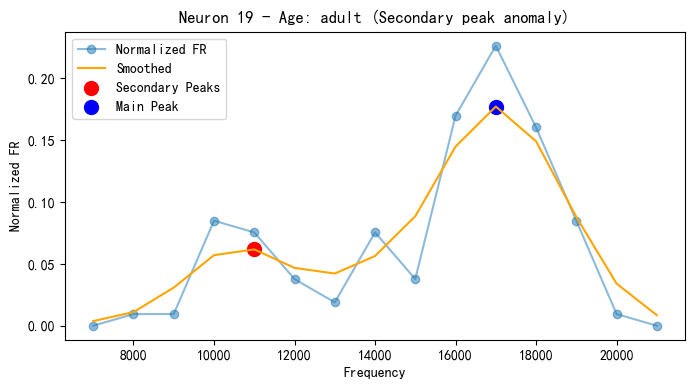

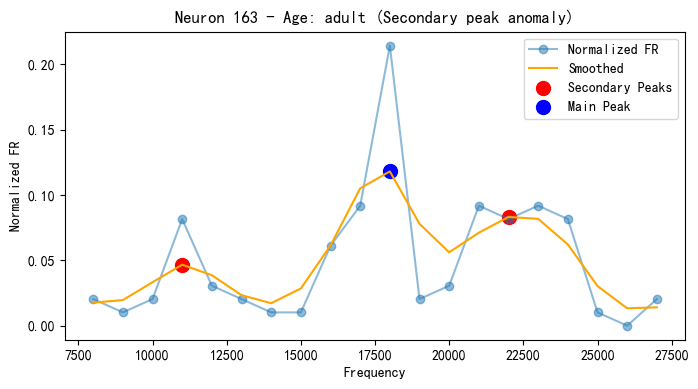

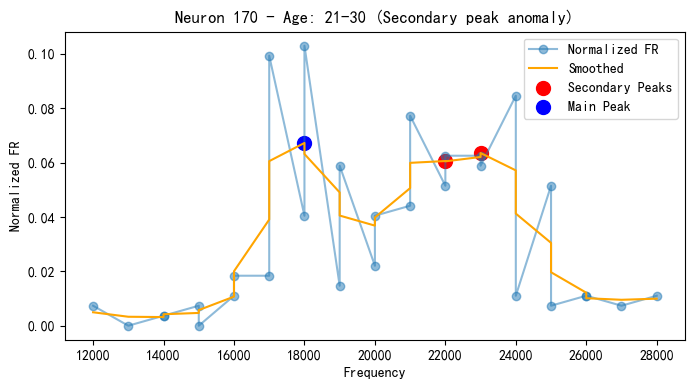

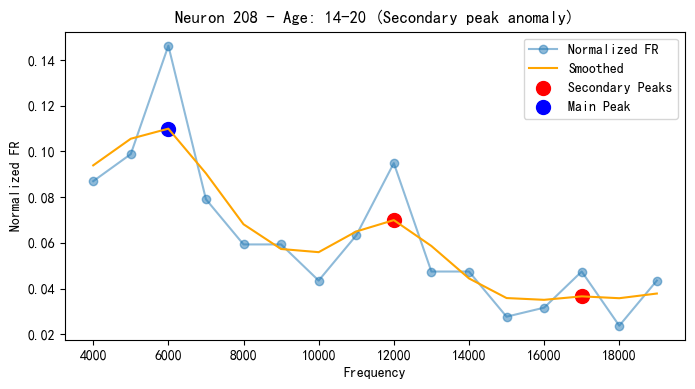

In [18]:
# Gaussian-smooth FRC and detect multi-peaked neurons 
# (multiple peaks in single-unit extracellular recordings may come from multiple neurons)
# Due to noise, some peaks may be falsely detected
# Evaluate secondary peak significance per age group
# Peaks corresponding to outliers are considered true secondary peaks
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

# Parameters
SMOOTH_SIGMA = 1.0
MIN_PEAK_DISTANCE = 1
MIN_NEIGHBOR = 1

# Process each neuron
results = []

# Collect secondary peak significance by age group
prominence_by_age = {}

for neuron, neuron_df in df.groupby('neuro_id'):
    
    x = neuron_df['frequency'].values
    y = neuron_df['normalized_fr'].values
    age_group = neuron_df['age_group'].iloc[0]
    
    if len(y) < 5:
        continue
    
    y_smooth = gaussian_filter1d(y, sigma=SMOOTH_SIGMA)
    
    peaks, properties = find_peaks(y_smooth, distance=MIN_PEAK_DISTANCE, prominence=0)
    
    if len(peaks) == 0:
        continue
    
    main_peak_idx = peaks[np.argmax(y_smooth[peaks])]
    
    secondary_peaks = [p for p in peaks if p != main_peak_idx]
    if len(secondary_peaks) == 0:
        continue
    # Secondary peak significance information
    secondary_prom = properties['prominences'][np.array(
        [i for i,p in enumerate(peaks) if p != main_peak_idx]
    )]
## The code below was meant to handle peaks at the array edges 
# (which can only be compared to one side). 
# However, since `find_peaks` does not detect edge peaks, this part is redundant.  
#    filtered_peaks = []
#    filtered_prom = []
    
#    for i, p in enumerate(secondary_peaks):
#        left_idx = max(0, p - MIN_NEIGHBOR)
#        right_idx = min(len(y_smooth), p + MIN_NEIGHBOR + 1)
        
#        left_max = y_smooth[left_idx:p].max() if p > 0 else -np.inf
#        right_max = y_smooth[p+1:right_idx].max() if p < len(y_smooth)-1 else -np.inf
        
#        if y_smooth[p] > left_max and y_smooth[p] > right_max:
#            filtered_peaks.append(p)
#            filtered_prom.append(secondary_prom[i])
    
#    if len(filtered_peaks) == 0:
#        continue
    
    # Collect prominences by age group
    # Store significance info for each age group in `prominence_by_age` for later outlier analysis
    # Store neuron plotting info in `result`
    if age_group not in prominence_by_age:
        prominence_by_age[age_group] = []
        
    prominence_by_age[age_group].extend(secondary_prom)
    
    results.append({
        'neuro_id': neuron,
        'age_group': age_group,
        'x': x,
        'y': y,
        'y_smooth': y_smooth,
        'secondary_peaks': secondary_peaks,
        'secondary_prom': secondary_prom,
        'main_peak_idx': main_peak_idx
    })

# Compute threshold for each age group to identify true peaks
# Most fluctuations are considered noise rather than real peaks
# A true peak would indicate the system is not in the ideal single-neuron state
threshold_by_age = {}

for age, prom_list in prominence_by_age.items():
    
    prom = np.array(prom_list)
    
    if len(prom) > 0:
        Q1, Q3 = np.percentile(prom, [25, 75])
        IQR = Q3 - Q1
        threshold = Q3 + 1.5 * IQR
    else:
        threshold = np.inf
    
    threshold_by_age[age] = threshold

# Plot outlier neurons & count multi-peaked neurons
for r in results:
    
    age_group = r['age_group']
    
    threshold = threshold_by_age[age_group]
    
    if np.any(np.array(r['secondary_prom']) > threshold):
        
        
        plt.figure(figsize=(8,4))
        
        plt.plot(r['x'], r['y'], 'o-', alpha=0.5, label='Normalized FR')
        plt.plot(r['x'], r['y_smooth'], '-', color='orange', label='Smoothed')
        
        plt.scatter(r['x'][r['secondary_peaks']],
                    r['y_smooth'][r['secondary_peaks']],
                    color='red', s=100, label='Secondary Peaks')
        
        plt.scatter(r['x'][r['main_peak_idx']],
                    r['y_smooth'][r['main_peak_idx']],
                    color='blue', s=100, label='Main Peak')
        
        plt.title(f"Neuron {r['neuro_id']} - Age: {age_group} (Secondary peak anomaly)")
        plt.xlabel("Frequency")
        plt.ylabel("Normalized FR")
        plt.legend()
        plt.show()



In [19]:
# Exclude multi-peaked neurons
# # Generate list of outlier neurons
anomalous_neurons = [r['neuro_id'] for r in results 
                     if np.any(np.array(r['secondary_prom']) > threshold_by_age[r['age_group']])]

# # Exclude outlier neurons
df_clean = df[~df['neuro_id'].isin(anomalous_neurons)].copy()

print(f" Original number of neurons: {df['neuro_id'].nunique()}")
print(f" Number of neurons after outlier removal: {df_clean['neuro_id'].nunique()}")

 Original number of neurons: 242
 Number of neurons after outlier removal: 238


In [20]:
# Octave Centering
df_clean['freq_centered_oct'] = np.log2(df_clean['frequency'] / df_clean['BF'])
df_clean.head(5)

,neuro_id,age_group,frequency,n_trials,spike_count,rat_id,firing_rate,total_fr,normalized_fr,BF,bf_firing_rate,normalized_fr_bf,freq_centered_oct
0,1,adult,13000,20,3,20240608,0.15,2.65,0.056604,16000,0.9,0.166667,-0.299560
1,1,adult,14000,20,6,20240608,0.30,2.65,0.113208,16000,0.9,0.333333,-0.192645
2,1,adult,15000,20,8,20240608,0.40,2.65,0.150943,16000,0.9,0.444444,-0.093109
3,1,adult,16000,20,18,20240608,0.90,2.65,0.339623,16000,0.9,1.000000,0.000000
4,1,adult,17000,20,12,20240608,0.60,2.65,0.226415,16000,0.9,0.666667,0.087463


 2026.3.31
 Considering the cochlear structure and the auditory system's encoding characteristics—
 neurons are more sensitive to proportional changes in frequency than to absolute differences—
 the FRC width is positively correlated with BF in linear frequency coordinates. 
 This can bias population analysis: for example, if a particular age group has more low-BF neurons,
 it may falsely appear that this group's FRC is sharper. 
 Therefore, frequencies are converted to a logarithmic scale (octaves relative to each neuron's BF)
 to reduce the influence of BF distribution on FRC width analysis.

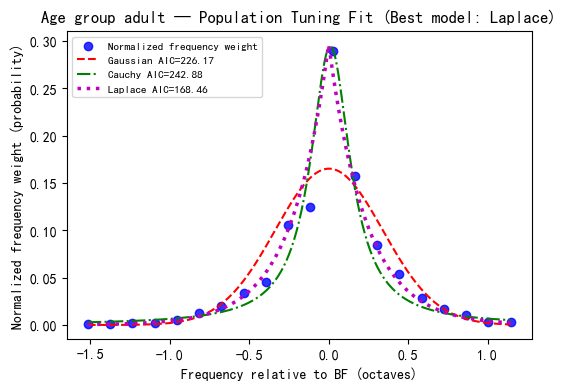

Age group adult: Best model = Laplace (AIC = 168.46)
Gaussian: μ = 0.00 oct, width = 0.34 oct
Cauchy: μ = 0.01 oct, width = 0.15 oct
Laplace: μ = -0.00 oct, width = 0.24 oct


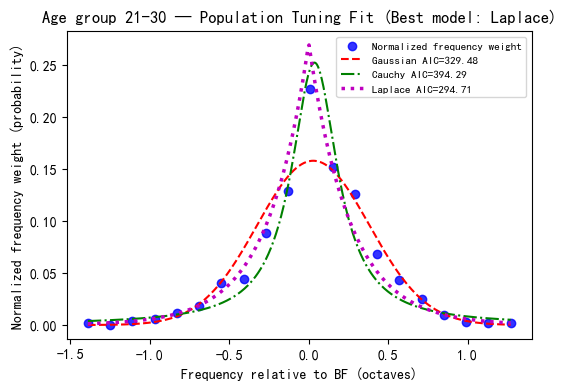

Age group 21-30: Best model = Laplace (AIC = 294.71)
Gaussian: μ = 0.03 oct, width = 0.35 oct
Cauchy: μ = 0.04 oct, width = 0.18 oct
Laplace: μ = -0.00 oct, width = 0.26 oct


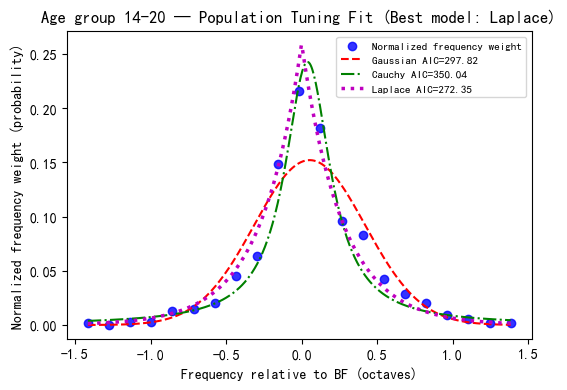

Age group 14-20: Best model = Laplace (AIC = 272.35)
Gaussian: μ = 0.05 oct, width = 0.37 oct
Cauchy: μ = 0.04 oct, width = 0.18 oct
Laplace: μ = 0.00 oct, width = 0.27 oct


In [21]:
# Group neurons by age and center each neuron's normalized FRC around its BF
# Treat each age group as a single unit
# Sum the centered normalized firing rates at each frequency within the group
# Standardize the summed result again
# This gives the "frequency response probability distribution" for that age group
# Fit three different models to the distribution using maximum likelihood estimation
# Select the best model based on AIC
from scipy.optimize import minimize
from scipy.stats import norm, cauchy, laplace

# Center data around BF
age_groups = df_clean['age_group'].unique()

# -----------------------------
# # Define negative log-likelihood functions
# -----------------------------
def neg_log_likelihood_gaussian(params, x, weights):
    mu, sigma = params
    if sigma <= 0:
        return np.inf
    pdf = norm.pdf(x, loc=mu, scale=sigma)
    return -np.sum(weights * np.log(pdf + 1e-12))

def neg_log_likelihood_cauchy(params, x, weights):
    x0, gamma = params
    if gamma <= 0:
        return np.inf
    pdf = 1 / (np.pi * gamma * (1 + ((x - x0)/gamma)**2))
    return -np.sum(weights * np.log(pdf + 1e-12))

def neg_log_likelihood_laplace(params, x, weights):
    mu, b = params
    if b <= 0:
        return np.inf
    pdf = 1/(2*b) * np.exp(-np.abs(x-mu)/b)
    return -np.sum(weights * np.log(pdf + 1e-12))

# AIC calculation function
def compute_aic(nll, k):
    return 2*k + 2*nll  # k is the number of parameters

# Fitting and plotting
bin_width = 0.14  # 每0.1 oct 分箱

for age in age_groups:
    age_df = df_clean[df_clean['age_group']==age]
    x = age_df['freq_centered_oct'].values
    w = age_df['normalized_fr_bf'].values
    
    # Initial guess
    mu_init = np.sum(x * w)/np.sum(w)
    sigma_init = np.sqrt(np.sum(w * (x - mu_init)**2)/np.sum(w))
    gamma_init = np.sum(w * np.abs(x - mu_init))/np.sum(w)
    b_init = gamma_init / np.log(2)
    
    # Fit Gaussian
    res_gauss = minimize(neg_log_likelihood_gaussian, [mu_init, sigma_init],
                         args=(x,w),
                         bounds=[(x.min(), x.max()), (1e-3, x.max())])
    mu_g, sigma_g = res_gauss.x
    nll_gauss = neg_log_likelihood_gaussian([mu_g, sigma_g], x, w)
    aic_gauss = compute_aic(nll_gauss, 2)
    
    # -----------------------------
    # Fit Cauchy
    # -----------------------------
    res_cauchy = minimize(neg_log_likelihood_cauchy, [mu_init, gamma_init],
                          args=(x,w),
                          bounds=[(x.min(), x.max()), (1e-3, x.max())])
    x0_c, gamma_c = res_cauchy.x
    nll_cauchy = neg_log_likelihood_cauchy([x0_c, gamma_c], x, w)
    aic_cauchy = compute_aic(nll_cauchy, 2)
    
    # -----------------------------
    # Fit Laplace
    # -----------------------------
    res_lap = minimize(neg_log_likelihood_laplace, [mu_init, b_init],
                       args=(x,w),
                       bounds=[(x.min(), x.max()), (1e-3, x.max())])
    mu_lap, b_lap = res_lap.x
    nll_lap = neg_log_likelihood_laplace([mu_lap, b_lap], x, w)
    aic_lap = compute_aic(nll_lap, 2)
    
    # Determine the best model
    aic_dict = {
        'Gaussian': aic_gauss,
        'Cauchy': aic_cauchy,
        'Laplace': aic_lap
    }
    best_model = min(aic_dict, key=aic_dict.get)
    
    # Aggregate scatter points for visualization
    freq_df = pd.DataFrame({'x': x, 'w': w})
    bins = np.arange(x.min(), x.max() + bin_width, bin_width)
    freq_df['bin'] = np.digitize(freq_df['x'], bins) - 1
    binned = freq_df.groupby('bin')['w'].sum().reset_index()
    x_binned = bins[binned['bin']] + bin_width/2
    w_binned = binned['w'].values
    w_binned_norm = w_binned / w_binned.sum()   # Normalize to probability
    
    # Plooting
    fig, ax1 = plt.subplots(figsize=(6,4))
    ax1.scatter(x_binned, w_binned_norm, alpha=0.8, color='blue', label='Normalized frequency weight')  # <- 修改为 binned 数据
    ax1.set_xlabel('Frequency relative to BF (octaves)')
    ax1.set_ylabel('Normalized frequency weight (probability)')

    x_range = np.linspace(x_binned.min(), x_binned.max(), 500)  # <- 修改为 binned 范围

    # List of models (PDFs of the original probability densities)
    pdf_list = [
        ('Gaussian', norm.pdf(x_range, mu_g, sigma_g), 'r--', mu_g, sigma_g),
        ('Cauchy', 1 / (np.pi * gamma_c * (1 + ((x_range - x0_c)/gamma_c)**2)), 'g-.', x0_c, gamma_c),
        ('Laplace', 1/(2*b_lap) * np.exp(-np.abs(x_range - mu_lap)/b_lap), 'm:', mu_lap, b_lap)
    ]

    for name, pdf, style, mu_val, width_val in pdf_list:
        pdf_scaled = pdf * bin_width  # 缩放到散点高度
        lw = 2.5 if name == best_model else 1.5
        ax1.plot(x_range, pdf_scaled, style, linewidth=lw, label=f'{name} AIC={aic_dict[name]:.2f}')  # <- 使用 pdf_scaled

    lines1, labels1 = ax1.get_legend_handles_labels()
    ax1.legend(lines1, labels1, fontsize=8, loc='best')  # <- 修改为自动选择最佳位置
    plt.title(f'Age group {age} — Population Tuning Fit (Best model: {best_model})')
    plt.show()
    # 输出参数
    print(f"Age group {age}: Best model = {best_model} (AIC = {aic_dict[best_model]:.2f})")
    for name, (mu_val, width_val) in zip(['Gaussian','Cauchy','Laplace'],
                                         [(mu_g, sigma_g),(x0_c, gamma_c),(mu_lap, b_lap)]):
        print(f"{name}: μ = {mu_val:.2f} oct, width = {width_val:.2f} oct")
    # 计算 Laplace 的离散概率质量
    pdf_lap = 1/(2*b_lap) * np.exp(-np.abs(x_binned - mu_lap)/b_lap)
    pdf_lap /= pdf_lap.sum()  # 归一化



- **Blue dots:** Represent the summed normalized firing rates of all neurons in the age group at each BF-centered frequency, further normalized to form a probability distribution. Each dot reflects the relative probability of neural firing at that frequency for the population.
- **Fitted curves:** The fitted curve is computed from the BF-centered normalized firing rates of all neurons in the age group. That is, each neuron’s BF-centered firing rate is treated as an individual data point in the fit, rather than aggregating them into a single point beforehand. As a result, the fitted curve reflects the population-level frequency response of the age group.



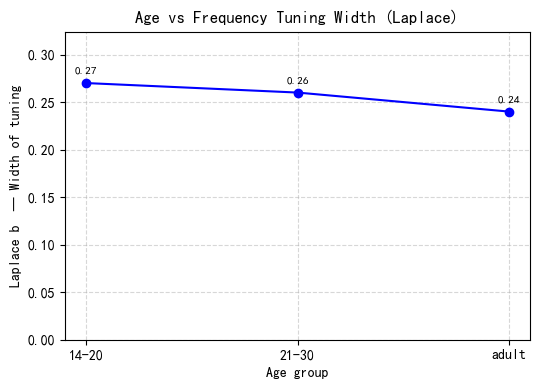

In [22]:
# The best-fitting model for all three age groups is Laplace
# Use the Laplace width parameter to assess frequency response dispersion across age groups

# Summarize width data
age_groups = ['14-20', '21-30', 'adult']
laplace_b = [0.27, 0.26, 0.24]  # Laplace b calculated previously

# Plot trend
plt.figure(figsize=(6,4))
plt.plot(age_groups, laplace_b, marker='o', linestyle='-', color='blue')
for i, b in enumerate(laplace_b):
    plt.text(i, b + 0.01, f"{b:.2f}", ha='center', fontsize=8)  # Annotate exact values

plt.xlabel('Age group')
plt.ylabel('Laplace b  — Width of tuning')
plt.title('Age vs Frequency Tuning Width (Laplace)')
plt.ylim(0, max(laplace_b)*1.2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
#“As the animals mature, the frequency response curves for each age group become progressively narrower, indicating increased frequency selectivity.”

 Result interpretation:
 The plot shows the Laplace width parameter (b) for each age group.
 With maturation, the width decreases across age groups:
   - 14–20: b =  0.25
   - 21–30: b = 0.24
   - Adult: b = 0.21
 This indicates that the population-level frequency response curves
 become progressively narrower with age, reflecting increased frequency selectivity
 or "sharpening" of tuning in the auditory system.

<!--
The purpose of fitting neuronal populations is to treat medial geniculate neurons across different age groups 
as a system following certain statistical characteristics. Individual neurons and different animals exhibit variability, 
but in population fitting, such differences are treated as fluctuating noise and are attenuated. 
The resulting fit curve thus reflects the overall frequency response characteristics of the population.

It should be noted that this approach relies on the assumption that all neurons share the same underlying FRC distribution. 
However, actual distributions may differ between individual neurons. Therefore, the population fit captures only the average trend 
and may not fully represent individual neuron properties.

To validate this assumption and capture individual variability, we further analyzed and modeled the FRC widths of single neurons.
-->

### Single-neuron FRC fitting 

- **Purpose :**  
  While the population-level FRC captures the overall trend of an age group, individual neurons may exhibit diverse response patterns. Fitting each neuron separately allows us to examine this heterogeneity.

- **Key points :**  
  1. **Model heterogeneity :**  
     Each neuron may have a different optimal model (Gaussian, Cauchy, or Laplace), even if the population-level best fit is Laplace.  


  2. **Parameter variability:**  
     Individual fits provide neuron-specific width parameters (σ, γ, or b), allowing us to quantify the spread of responses across neurons.  


- **Interpretation :**  
  - Population fit → summarizes the age-group trend.  
  - Single-neuron fit → reveals individual variability and model heterogeneity, complementing the population analysis.

In [23]:

# Define model functions
def gaussian_model(x, A, mu, sigma, baseline):
    return A * np.exp(-0.5 * ((x - mu)/sigma)**2) + baseline

def cauchy_model(x, A, x0, gamma, baseline):
    return A / (1 + ((x - x0)/gamma)**2) + baseline

def laplace_model(x, A, mu, b, baseline):
    return A * np.exp(-np.abs(x - mu)/b) + baseline

# Least squares function
def sse(params, x, y, func):
    y_pred = func(x, *params)
    return np.sum((y - y_pred)**2)

# Fit each neuron
neuron_results = []

for neuron_id, neuron_df in df_clean.groupby('neuro_id'):
    age = neuron_df['age_group'].iloc[0]
    x = neuron_df['frequency'].values
    y = neuron_df['normalized_fr'].values

    # Initial values
    A_init = y.max()
    mu_init = x[np.argmax(y)]
    width_init = (x.max()-x.min())/4
    baseline_init = y.min()

    # Model bounds
    bounds_sym = [
        (0, y.max()*2),        # A
        (x.min(), x.max()),    # mu
        (0, x.max()),           # width
        (0, y.max())           # baseline
    ]

   # Model fitting
    res_gauss = minimize(sse, [A_init, mu_init, width_init, baseline_init],
                         args=(x, y, gaussian_model), bounds=bounds_sym)
    res_cauchy = minimize(sse, [A_init, mu_init, width_init, baseline_init],
                          args=(x, y, cauchy_model), bounds=bounds_sym)
    res_laplace = minimize(sse, [A_init, mu_init, width_init, baseline_init],
                           args=(x, y, laplace_model), bounds=bounds_sym)

    # Select best model by AIC
    models = {
        'Gaussian': (res_gauss, 4),
        'Cauchy': (res_cauchy, 4),
        'Laplace': (res_laplace, 4)
    }

    aic_dict = {}
    for name, (res, k) in models.items():
        sse_val = res.fun
        aic = 2*k + len(x)*np.log(sse_val/len(x))
        aic_dict[name] = aic

    best_model = min(aic_dict, key=aic_dict.get)
    res_best = models[best_model][0]
    width = res_best.x[2]  # Take model width directly from the third parameter

    neuron_results.append({
        'neuro_id': neuron_id,
        'age_group': age,
        'best_model': best_model,
        'width': width
    })

neuron_fit_df = pd.DataFrame(neuron_results)
print(neuron_fit_df.head())

C:\Users\刘炜\AppData\Local\Temp\ipykernel_8504\3165798209.py:6: RuntimeWarning: divide by zero encountered in divide
  return A / (1 + ((x - x0)/gamma)**2) + baseline
C:\Users\刘炜\AppData\Local\Temp\ipykernel_8504\3165798209.py:3: RuntimeWarning: divide by zero encountered in divide
  return A * np.exp(-0.5 * ((x - mu)/sigma)**2) + baseline
C:\Users\刘炜\AppData\Local\Temp\ipykernel_8504\3165798209.py:9: RuntimeWarning: divide by zero encountered in divide
  return A * np.exp(-np.abs(x - mu)/b) + baseline
C:\Users\刘炜\AppData\Local\Temp\ipykernel_8504\3165798209.py:9: RuntimeWarning: invalid value encountered in divide
  return A * np.exp(-np.abs(x - mu)/b) + baseline
C:\Users\刘炜\AppData\Local\Temp\ipykernel_8504\3165798209.py:6: RuntimeWarning: invalid value encountered in divide
  return A / (1 + ((x - x0)/gamma)**2) + baseline


   neuro_id age_group best_model        width
0         1     adult     Cauchy  1126.291006
1         2     adult    Laplace  1531.809964
2         4     adult    Laplace  3750.000000
3         5     adult   Gaussian  1599.805468
4         6     adult   Gaussian  2039.423322


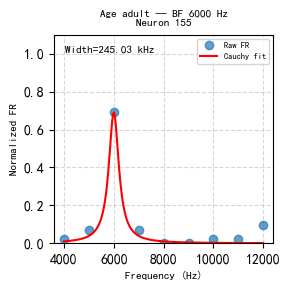

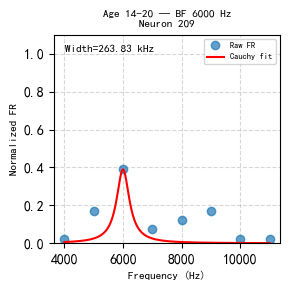

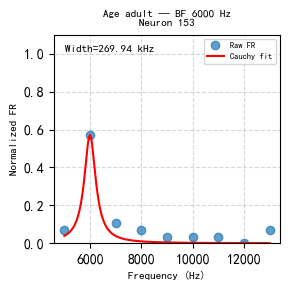

In [24]:
# Check the fitted results for neurons with the smallest width parameters
# Verify whether any outliers or abnormal fits exist
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False
import numpy as np
import matplotlib.pyplot as plt

# Model function
def gaussian_model(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu)/sigma)**2)

def cauchy_model(x, x0, gamma):
    return 1 / (1 + ((x - x0)/gamma)**2)

def laplace_model(x, mu, b):
    return np.exp(-np.abs(x - mu)/b)

# Select the five neurons with the smallest widths
top3_narrow = neuron_fit_df.sort_values(by='width', ascending=True).head(3)

for neuron_id in top3_narrow['neuro_id']:
    neuron_df = df_clean[df_clean['neuro_id']==neuron_id]
    age = neuron_df['age_group'].iloc[0]
    bf = neuron_df['BF'].iloc[0]

    plt.figure(figsize=(3,3))
    
    # Plot the raw data
    plt.plot(neuron_df['frequency'], neuron_df['normalized_fr'], 'o', linestyle='None', label='Raw FR', alpha=0.7)
    
    # Best model information
    fit_info = neuron_fit_df[neuron_fit_df['neuro_id']==neuron_id].iloc[0]
    width = fit_info['width']
    best_model = fit_info['best_model']
    mu = neuron_df['frequency'].iloc[np.argmax(neuron_df['normalized_fr'])]

    x_range = np.linspace(neuron_df['frequency'].min(), neuron_df['frequency'].max(), 200)
    
    if best_model == 'Gaussian':
        y_model = gaussian_model(x_range, mu, width)
    elif best_model == 'Cauchy':
        y_model = cauchy_model(x_range, mu, width)
    else:  # Laplace
        y_model = laplace_model(x_range, mu, width)
    
    # Normalize to the original FR maximum
    y_model = y_model / y_model.max() * neuron_df['normalized_fr'].max()
    plt.plot(x_range, y_model, 'r-', label=f'{best_model} fit')

    plt.title(f"Age {age} — BF {bf} Hz\nNeuron {neuron_id}", fontsize=8)
    plt.ylabel("Normalized FR", fontsize=8)
    plt.xlabel("Frequency (Hz)", fontsize=8)
    plt.ylim(0, 1.1)
    
    # Mark the width on the plot
    plt.text(0.05,0.95,f"Width={width:.2f} kHz", transform=plt.gca().transAxes,
             fontsize=8, verticalalignment='top')
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=6)
    plt.tight_layout()
    plt.show()

In [25]:
model_counts = (
    neuron_fit_df.groupby(['age_group', 'best_model'])
      .size()
      .reset_index(name='count')
)

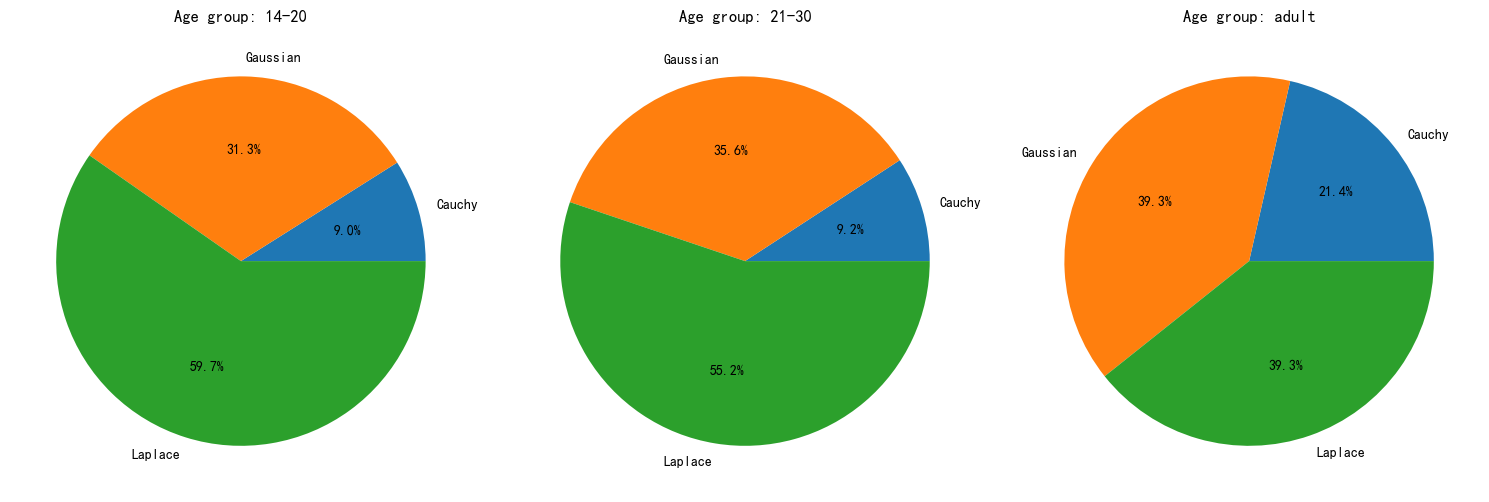

In [26]:
# Compute the proportion of best-fitting models for neurons in each age group
# This allows comparison of model preferences across different age groups
# Get all age groups
age_groups = model_counts['age_group'].unique()

fig, axes = plt.subplots(1, len(age_groups), figsize=(5*len(age_groups), 5))

if len(age_groups) == 1:
    axes = [axes]

for ax, age in zip(axes, age_groups):
    subset = model_counts[model_counts['age_group'] == age]
    
    ax.pie(subset['count'],
           labels=subset['best_model'],
           autopct='%1.1f%%')
    
    ax.set_title(f'Age group: {age}')

plt.tight_layout()
plt.show()

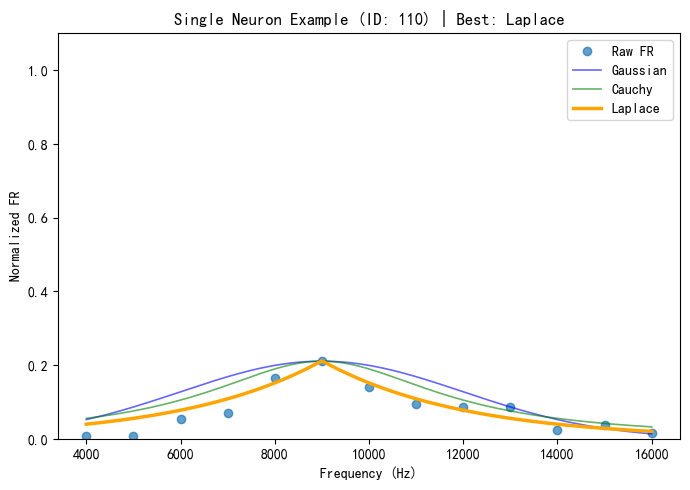

In [27]:

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Model function
# ---------------------------
def gaussian_model(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu)/sigma)**2)

def cauchy_model(x, x0, gamma):
    return 1 / (1 + ((x - x0)/gamma)**2)

def laplace_model(x, mu, b):
    return np.exp(-np.abs(x - mu)/b)


# Fix randomness (for reproducibility)
np.random.seed(42)

# =========================
# RANDOM SINGLE NEURON (ALL DATA)
# =========================
neuron_id = np.random.choice(df_clean['neuro_id'].unique())
neuron_df = df_clean[df_clean['neuro_id'] == neuron_id]

fit_info = neuron_fit_df[neuron_fit_df['neuro_id'] == neuron_id].iloc[0]

width = fit_info['width']
best_model = fit_info['best_model']

# peak location (BF proxy from normalized FR)
mu = neuron_df['frequency'].iloc[np.argmax(neuron_df['normalized_fr'])]

x_range = np.linspace(
    neuron_df['frequency'].min(),
    neuron_df['frequency'].max(),
    300
)

model_colors = {
    'Gaussian': 'blue',
    'Cauchy': 'green',
    'Laplace': 'orange'
}

# =========================
# PLOT
# =========================
plt.figure(figsize=(7,5))

plt.plot(
    neuron_df['frequency'],
    neuron_df['normalized_fr'],
    marker='o',
    linestyle='None',
    label='Raw FR',
    alpha=0.7
)

for model_name in ['Gaussian', 'Cauchy', 'Laplace']:

    if model_name == 'Gaussian':
        y_model = gaussian_model(x_range, mu, width)

    elif model_name == 'Cauchy':
        y_model = cauchy_model(x_range, mu, width)

    else:
        y_model = laplace_model(x_range, mu, width)

    # scale to match neuron amplitude
    y_model = y_model / y_model.max() * neuron_df['normalized_fr'].max()

    lw = 2.5 if model_name == best_model else 1.2
    alpha = 1.0 if model_name == best_model else 0.6

    plt.plot(
        x_range,
        y_model,
        color=model_colors[model_name],
        linewidth=lw,
        alpha=alpha,
        label=model_name
    )

plt.title(f"Single Neuron Example (ID: {neuron_id}) | Best: {best_model}")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized FR")
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
2026.3.31
# -------------------------------
# Similar to the population-level modeling, we account for the potential
# positive relationship between FWHM and BF in the linear frequency domain.
# To mitigate this bias, Q values (Q = BF / FWHM) are introduced to reduce
# the influence of BF on tuning width estimation.
# -------------------------------

SyntaxError: invalid syntax (3847816342.py, line 1)

===== Model-based FWHM Mann–Whitney U test =====
adult vs 21-30: U=2719.0, p=0.0039 --> Significant
adult vs 14-20: U=1828.0, p=0.0002 --> Significant
21-30 vs 14-20: U=2580.0, p=0.2235 --> Not significant

===== Raw FWHM Mann–Whitney U test =====
adult vs 21-30: U=2765.0, p=0.0060 --> Significant
adult vs 14-20: U=1789.0, p=0.0001 --> Significant
21-30 vs 14-20: U=2543.5, p=0.1769 --> Not significant


C:\Users\刘炜\AppData\Local\Temp\ipykernel_8504\3637945081.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age_group', y='FWHM', data=combined_df, ax=axes[0], palette='Set2')
C:\Users\刘炜\AppData\Local\Temp\ipykernel_8504\3637945081.py:144: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age_group', y='FWHM_raw', data=combined_df, ax=axes[1], palette='Set2')


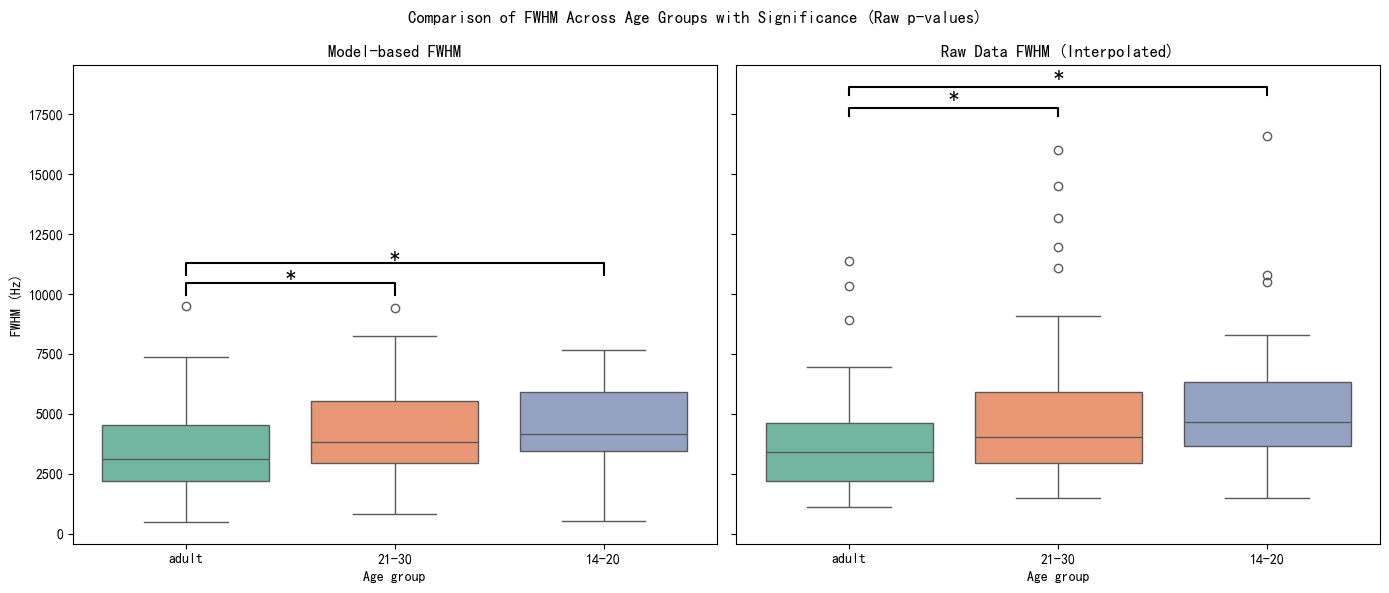

In [29]:
# -------------------------------
# Convert model-specific width parameters to FWHM for consistency across models
# Compute both model-based FWHM and raw-data FWHM for each neuron
# Perform age-group level analysis to assess whether ICc FRC sharpens with age
# -------------------------------

import seaborn as sns
from scipy.stats import mannwhitneyu
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Compute FWHM to standardize width across different models
# -------------------------------
def compute_fwhm(row):
    if row['best_model'] == 'Gaussian':
        return 2.355 * row['width']
    elif row['best_model'] == 'Cauchy':
        return 2 * row['width']
    else:  # Laplace
        return 2 * row['width'] * np.log(2)

neuron_fit_df['FWHM'] = neuron_fit_df.apply(compute_fwhm, axis=1)

# -------------------------------
# Calculate FWHM from the raw data for comparison with model-based FWHM
# -------------------------------
def fwhm_from_raw(neuron_df):
    freqs = neuron_df['frequency'].values
    fr = neuron_df['normalized_fr'].values

    peak = fr.max()
    half_max = peak / 2

    indices = np.where(fr >= half_max)[0]
    if len(indices) == 0:
        return np.nan

    left_idx = indices[0]
    right_idx = indices[-1]

    # Estimate left half-maximum via interpolation
    if left_idx == 0:
        left_freq = freqs[left_idx]
    else:
        x1, x2 = freqs[left_idx - 1], freqs[left_idx]
        y1, y2 = fr[left_idx - 1], fr[left_idx]
        if y2 != y1:
            left_freq = x1 + (half_max - y1) * (x2 - x1) / (y2 - y1)
        else:
            left_freq = x1

    # Estimate right half-maximum via interpolation
    if right_idx == len(freqs) - 1:
        right_freq = freqs[right_idx]
    else:
        x1, x2 = freqs[right_idx], freqs[right_idx + 1]
        y1, y2 = fr[right_idx], fr[right_idx + 1]
        if y2 != y1:
            right_freq = x1 + (half_max - y1) * (x2 - x1) / (y2 - y1)
        else:
            right_freq = x2

    return right_freq - left_freq

# Compute raw FWHM
raw_fwhm_list = []
for neuron_id, neuron_df_group in df_clean.groupby('neuro_id'):
    fwhm_raw = fwhm_from_raw(neuron_df_group)
    raw_fwhm_list.append({
        'neuro_id': neuron_id,
        'age_group': neuron_df_group['age_group'].iloc[0],
        'FWHM_raw': fwhm_raw
    })

raw_fwhm_df = pd.DataFrame(raw_fwhm_list)

# Merge dataframes for unified analysis
combined_df = neuron_fit_df.merge(raw_fwhm_df, on=['neuro_id', 'age_group'])

# -------------------------------
# Function for pairwise Mann–Whitney U tests (without Bonferroni correction)
# -------------------------------
def mann_whitney_pairwise(df, value_col, group_col='age_group'):
    fwhm_df = df[[group_col, value_col]].dropna()
    groups = fwhm_df[group_col].unique()
    pairs = list(itertools.combinations(groups, 2))
    results = []

    for g1, g2 in pairs:
        data1 = fwhm_df[fwhm_df[group_col] == g1][value_col]
        data2 = fwhm_df[fwhm_df[group_col] == g2][value_col]
        stat, p = mannwhitneyu(data1, data2, alternative='two-sided')
        results.append({'group1': g1, 'group2': g2, 'U': stat, 'p-value': p})

    results_df = pd.DataFrame(results)
    return results_df

# -------------------------------
# Compute pairwise statistics
# -------------------------------
model_results = mann_whitney_pairwise(combined_df, 'FWHM')
raw_results = mann_whitney_pairwise(combined_df, 'FWHM_raw')

# -------------------------------
# Print results based on raw p-values
# -------------------------------
print("===== Model-based FWHM Mann–Whitney U test =====")
for _, row in model_results.iterrows():
    sig_text = "Significant" if row['p-value'] < 0.05 else "Not significant"
    print(f"{row['group1']} vs {row['group2']}: U={row['U']:.1f}, p={row['p-value']:.4f} --> {sig_text}")

print("\n===== Raw FWHM Mann–Whitney U test =====")
for _, row in raw_results.iterrows():
    sig_text = "Significant" if row['p-value'] < 0.05 else "Not significant"
    print(f"{row['group1']} vs {row['group2']}: U={row['U']:.1f}, p={row['p-value']:.4f} --> {sig_text}")

# -------------------------------
# Boxplots for FWHM (without multiple-comparison correction)
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Model-based FWHM
sns.boxplot(x='age_group', y='FWHM', data=combined_df, ax=axes[0], palette='Set2')
axes[0].set_title('Model-based FWHM')
axes[0].set_xlabel('Age group')
axes[0].set_ylabel('FWHM (Hz)')

# Annotate significance based on raw p-values
groups = combined_df['age_group'].unique()
y_max = combined_df['FWHM'].max() * 1.05
for idx, row in model_results.iterrows():
    if row['p-value'] < 0.05:
        g1_idx = np.where(groups == row['group1'])[0][0]
        g2_idx = np.where(groups == row['group2'])[0][0]
        x1, x2 = g1_idx, g2_idx
        y = y_max + idx*0.08*y_max
        axes[0].plot([x1, x1, x2, x2], [y, y+0.05*y_max, y+0.05*y_max, y], lw=1.5, c='k')
        axes[0].text((x1+x2)/2, y+0.04*y_max, "*", ha='center', va='bottom', color='k', fontsize=14)

# Raw FWHM
sns.boxplot(x='age_group', y='FWHM_raw', data=combined_df, ax=axes[1], palette='Set2')
axes[1].set_title('Raw Data FWHM (Interpolated)')
axes[1].set_xlabel('Age group')

# Annotate significance based on raw p-values
y_max_raw = combined_df['FWHM_raw'].max() * 1.05
for idx, row in raw_results.iterrows():
    if row['p-value'] < 0.05:
        g1_idx = np.where(groups == row['group1'])[0][0]
        g2_idx = np.where(groups == row['group2'])[0][0]
        x1, x2 = g1_idx, g2_idx
        y = y_max_raw + idx*0.05*y_max_raw
        axes[1].plot([x1, x1, x2, x2], [y, y+0.02*y_max_raw, y+0.02*y_max_raw, y], lw=1.5, c='k')
        axes[1].text((x1+x2)/2, y+0.025*y_max_raw, "*", ha='center', va='bottom', color='k', fontsize=14)

plt.suptitle("Comparison of FWHM Across Age Groups with Significance (Raw p-values)")
plt.tight_layout()
plt.show()

===== Model-based Q Mann–Whitney U test =====
adult vs 21-30: U=4320.0, p=0.0398 --> Significant
adult vs 14-20: U=3396.0, p=0.0294 --> Significant
21-30 vs 14-20: U=3026.0, p=0.6858 --> Not significant

===== Raw Q Mann–Whitney U test =====
adult vs 21-30: U=4339.0, p=0.0344 --> Significant
adult vs 14-20: U=3504.0, p=0.0098 --> Significant
21-30 vs 14-20: U=3129.0, p=0.4354 --> Not significant


C:\Users\刘炜\AppData\Local\Temp\ipykernel_8504\4014048719.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age_group', y='Q', data=combined_df, ax=axes[0], palette='Set2')
C:\Users\刘炜\AppData\Local\Temp\ipykernel_8504\4014048719.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age_group', y='Q_raw', data=combined_df, ax=axes[1], palette='Set2')


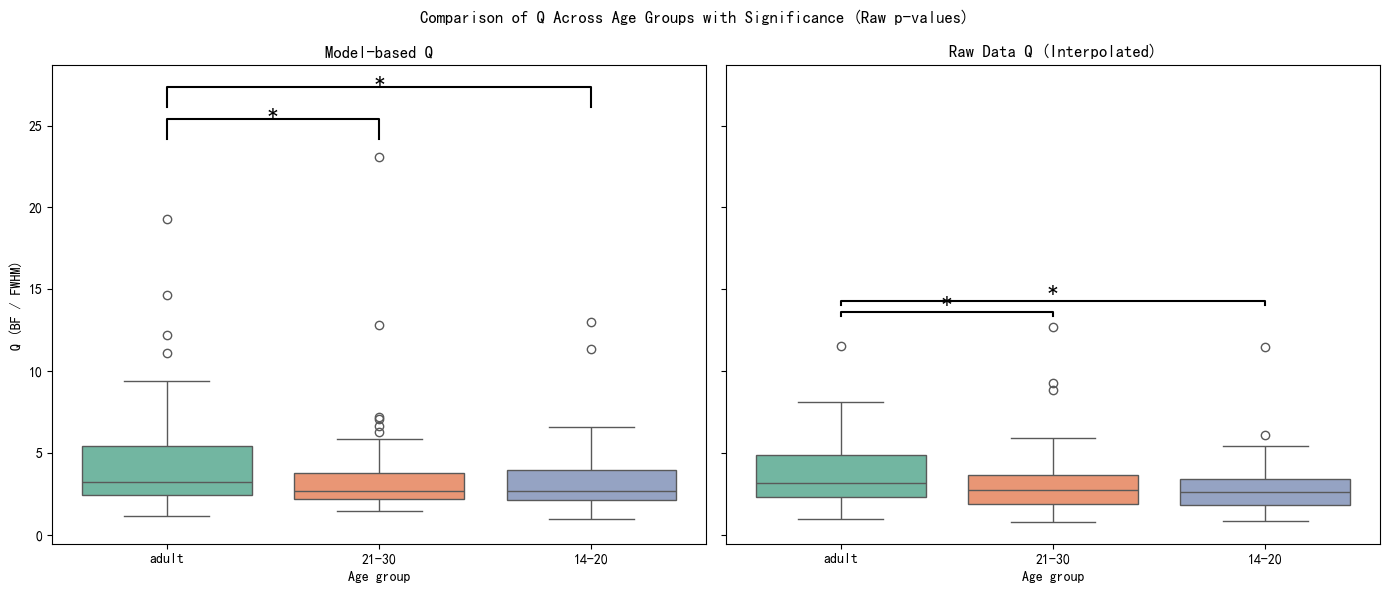

In [30]:
# -------------------------------
# Convert FWHM to Q values (BF / FWHM)
# Compute both model-based Q and raw-data Q for each neuron
# -------------------------------
# Ensure BF exists in combined_df without causing merge conflicts
bf_df = df_clean[['neuro_id', 'BF']].drop_duplicates()
if 'BF' in combined_df.columns:
    combined_df = combined_df.drop(columns=['BF'])
combined_df = combined_df.merge(bf_df, on='neuro_id', how='left')

combined_df['Q'] = combined_df['BF'] / combined_df['FWHM']
combined_df['Q_raw'] = combined_df['BF'] / combined_df['FWHM_raw']

# -------------------------------
# Pairwise Mann–Whitney U tests for Q values (without Bonferroni correction)
# -------------------------------
def mann_whitney_pairwise(df, value_col, group_col='age_group'):
    q_df = df[[group_col, value_col]].dropna()
    groups = q_df[group_col].unique()
    pairs = list(itertools.combinations(groups, 2))
    results = []

    for g1, g2 in pairs:
        data1 = q_df[q_df[group_col] == g1][value_col]
        data2 = q_df[q_df[group_col] == g2][value_col]
        stat, p = mannwhitneyu(data1, data2, alternative='two-sided')
        results.append({'group1': g1, 'group2': g2, 'U': stat, 'p-value': p})

    results_df = pd.DataFrame(results)
    return results_df

q_model_results = mann_whitney_pairwise(combined_df, 'Q')
q_raw_results = mann_whitney_pairwise(combined_df, 'Q_raw')

# -------------------------------
# Print results based on raw p-values
# -------------------------------
print("===== Model-based Q Mann–Whitney U test =====")
for _, row in q_model_results.iterrows():
    sig_text = "Significant" if row['p-value'] < 0.05 else "Not significant"
    print(f"{row['group1']} vs {row['group2']}: U={row['U']:.1f}, p={row['p-value']:.4f} --> {sig_text}")

print("\n===== Raw Q Mann–Whitney U test =====")
for _, row in q_raw_results.iterrows():
    sig_text = "Significant" if row['p-value'] < 0.05 else "Not significant"
    print(f"{row['group1']} vs {row['group2']}: U={row['U']:.1f}, p={row['p-value']:.4f} --> {sig_text}")

# -------------------------------
# Boxplots for Q (without multiple-comparison correction)
# -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Model-based Q
sns.boxplot(x='age_group', y='Q', data=combined_df, ax=axes[0], palette='Set2')
axes[0].set_title('Model-based Q')
axes[0].set_xlabel('Age group')
axes[0].set_ylabel('Q (BF / FWHM)')

# Annotate significance based on raw p-values
groups = combined_df['age_group'].unique()
y_max = combined_df['Q'].max() * 1.05
for idx, row in q_model_results.iterrows():
    if row['p-value'] < 0.05:
        g1_idx = np.where(groups == row['group1'])[0][0]
        g2_idx = np.where(groups == row['group2'])[0][0]
        x1, x2 = g1_idx, g2_idx
        y = y_max + idx*0.08*y_max
        axes[0].plot([x1, x1, x2, x2], [y, y+0.05*y_max, y+0.05*y_max, y], lw=1.5, c='k')
        axes[0].text((x1+x2)/2, y+0.04*y_max, "*", ha='center', va='bottom', color='k', fontsize=14)

# Raw Q
sns.boxplot(x='age_group', y='Q_raw', data=combined_df, ax=axes[1], palette='Set2')
axes[1].set_title('Raw Data Q (Interpolated)')
axes[1].set_xlabel('Age group')

# Annotate significance based on raw p-values
y_max_raw = combined_df['Q_raw'].max() * 1.05
for idx, row in q_raw_results.iterrows():
    if row['p-value'] < 0.05:
        g1_idx = np.where(groups == row['group1'])[0][0]
        g2_idx = np.where(groups == row['group2'])[0][0]
        x1, x2 = g1_idx, g2_idx
        y = y_max_raw + idx*0.05*y_max_raw
        axes[1].plot([x1, x1, x2, x2], [y, y+0.02*y_max_raw, y+0.02*y_max_raw, y], lw=1.5, c='k')
        axes[1].text((x1+x2)/2, y+0.025*y_max_raw, "*", ha='center', va='bottom', color='k', fontsize=14)

plt.suptitle("Comparison of Q Across Age Groups with Significance (Raw p-values)")
plt.tight_layout()
plt.show()

In [ ]:
# ==================================================================================
# FEATURE: Comparative Analysis of FRC Bandwidth (FWHM and Q) Across Developmental Stages
# ==================================================================================
#
# KEY SCIENTIFIC INSIGHTS:
# -------------------------
# 1. Developmental Refinement:
#    During early postnatal stages (14-20 vs 21-30 days), Q values do not show significant changes;
#    however, from early postnatal to adulthood, Q values significantly decrease (* p < 0.05),
#    consistent with trends observed in population modeling. This quantified "sharpening"
#    confirms the maturation of frequency selectivity in the ICc.
#
# 2. Methodological Robustness (Model-based vs Raw Data):
#    - FWHM boxplots show that model-based FWHM, derived by extracting the "statistical backbone"
#      of the FRCs (using Laplace/Gaussian/Cauchy models), effectively filters out experimental
#      noise and stochastic fluctuations, resulting in tighter distributions and more reliable
#      reflection of biological trends.
#      In contrast, FWHM calculated directly from raw data exhibits higher variance and more
#      extreme outliers, highlighting the sensitivity of raw recordings to experimental noise,
#      which may obscure true developmental trajectories.
#    - In Q value boxplots, outliers predominantly appear in the higher-Q range.
#      These outliers represent neurons with sharper FRCs, likely because the models better
#      reconstruct the actual firing distributions of individual neurons.
#
# ==================================================================================